# Hotel booking cancellation

Can we tell, from a reservation, whether the guest is going to cancel?

The data is public: two hotels in Portugal (one city, one resort), arrivals
from July 2015 to August 2017. Source: Antonio, Almeida & Nunes,
[*Scientific Data*, 2019](https://www.nature.com/articles/s41597-019-0075-9).

People search for this as “hotel churn”. It is booking cancellations, not
subscription churn. Same idea though.

**Label:** `is_canceled` — 1 if the booking was canceled or the guest was a
no-show, 0 if they checked out.

I am going to:

1. Clean the table (duplicates, missing values, a few impossible rows)
2. Look at cancel rates by lead time, channel, deposit, and so on
3. Train a model using only information that is known when the booking is made
4. Score it on 2017, which the model does not train on

Run this notebook from the repo root so `data/hotel_bookings.csv` resolves.


In [1]:
from pathlib import Path

import joblib
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
from sklearn.compose import ColumnTransformer
from sklearn.dummy import DummyClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (
    accuracy_score,
    classification_report,
    confusion_matrix,
    f1_score,
    precision_score,
    recall_score,
    roc_auc_score,
    roc_curve,
)
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder, StandardScaler

sns.set_theme(style="whitegrid", context="notebook")
plt.rcParams["figure.dpi"] = 120
plt.rcParams["savefig.dpi"] = 140
plt.rcParams["savefig.bbox"] = "tight"
plt.rcParams["axes.titlesize"] = 12
plt.rcParams["axes.labelsize"] = 11

STAY = "#4C78A8"
CANCEL = "#E45756"


def repo_root() -> Path:
    cwd = Path.cwd().resolve()
    for candidate in [cwd, cwd.parent]:
        if (candidate / "data" / "hotel_bookings.csv").exists():
            return candidate
    return cwd


ROOT = repo_root()
DATA_PATH = ROOT / "data" / "hotel_bookings.csv"
FIG_DIR = ROOT / "reports" / "figures"
MODEL_DIR = ROOT / "models"
FIG_DIR.mkdir(parents=True, exist_ok=True)
MODEL_DIR.mkdir(parents=True, exist_ok=True)

assert DATA_PATH.exists(), f"missing {DATA_PATH}"
print("loaded", DATA_PATH.name)
print("figures ->", FIG_DIR.relative_to(ROOT))


loaded hotel_bookings.csv
figures -> reports/figures


## 1. Load the data

`NULL` in this CSV means missing, not the string `"NULL"`.


In [2]:
df_raw = pd.read_csv(DATA_PATH, na_values=["NULL", "NA", ""])
print("rows, columns:", df_raw.shape)
df_raw.head()


rows, columns: (119390, 32)


,hotel,is_canceled,lead_time,arrival_date_year,arrival_date_month,arrival_date_week_number,arrival_date_day_of_month,stays_in_weekend_nights,stays_in_week_nights,adults,...,deposit_type,agent,company,days_in_waiting_list,customer_type,adr,required_car_parking_spaces,total_of_special_requests,reservation_status,reservation_status_date
0,Resort Hotel,0,342,2015,July,27,1,0,0,2,...,No Deposit,NaN,NaN,0,Transient,0.0,0,0,Check-Out,2015-07-01
1,Resort Hotel,0,737,2015,July,27,1,0,0,2,...,No Deposit,NaN,NaN,0,Transient,0.0,0,0,Check-Out,2015-07-01
2,Resort Hotel,0,7,2015,July,27,1,0,1,1,...,No Deposit,NaN,NaN,0,Transient,75.0,0,0,Check-Out,2015-07-02
3,Resort Hotel,0,13,2015,July,27,1,0,1,1,...,No Deposit,304.0,NaN,0,Transient,75.0,0,0,Check-Out,2015-07-02
4,Resort Hotel,0,14,2015,July,27,1,0,2,2,...,No Deposit,240.0,NaN,0,Transient,98.0,0,1,Check-Out,2015-07-03


In [3]:
df_raw.info()


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 119390 entries, 0 to 119389
Data columns (total 32 columns):
 #   Column                          Non-Null Count   Dtype  
---  ------                          --------------   -----  
 0   hotel                           119390 non-null  object 
 1   is_canceled                     119390 non-null  int64  
 2   lead_time                       119390 non-null  int64  
 3   arrival_date_year               119390 non-null  int64  
 4   arrival_date_month              119390 non-null  object 
 5   arrival_date_week_number        119390 non-null  int64  
 6   arrival_date_day_of_month       119390 non-null  int64  
 7   stays_in_weekend_nights         119390 non-null  int64  
 8   stays_in_week_nights            119390 non-null  int64  
 9   adults                          119390 non-null  int64  
 10  children                        119386 non-null  float64
 11  babies                          119390 non-null  int64  
 12  meal            

In [4]:
missing = df_raw.isna().sum()
missing = missing[missing > 0].sort_values(ascending=False)
print("columns with missing values:")
print(missing)
print()
print("exact duplicate rows:", int(df_raw.duplicated().sum()))
print("cancel rate (raw):", round(df_raw["is_canceled"].mean(), 4))
print(df_raw["is_canceled"].value_counts())
print()
print("reservation_status vs is_canceled:")
print(pd.crosstab(df_raw["reservation_status"], df_raw["is_canceled"]))


columns with missing values:
company     112593
agent        16340
country        488
children         4
dtype: int64



exact duplicate rows: 31994
cancel rate (raw): 0.3704
is_canceled
0    75166
1    44224
Name: count, dtype: int64

reservation_status vs is_canceled:
is_canceled             0      1
reservation_status              
Canceled                0  43017
Check-Out           75166      0
No-Show                 0   1207


A few things jump out:

- **119,390** rows, **31,994** exact duplicates. Duplicates in this dataset
  are mostly repeated canceled city-hotel bookings, so they inflate the
  cancel rate (raw is 37.0%).
- `company` is missing on most rows. `agent` is missing on some. Those look
  like IDs, not useful as numbers.
- `reservation_status` is a perfect map onto the label: `Check-Out` = stayed,
  `Canceled` / `No-Show` = canceled. I will drop it. Same for
  `reservation_status_date`.


## 2. Cleaning

Rules I am using:

- Drop exact duplicate rows
- Drop bookings with zero guests (no adults, children, or babies)
- `children`: 4 missing values → 0
- `country`: missing → `"Unknown"` (I am not going to pretend they are
  Portuguese)
- `Undefined` meal → `SC` (self-catering, which is the usual reading)
- `Undefined` market / channel → `"Other"`
- Clip a single negative ADR to 0. I will cap extreme ADR later, using the
  **training** set only
- Drop `reservation_status`, `reservation_status_date`, `assigned_room_type`
  (assigned room is usually known at check-in, not at booking)


In [5]:
n_raw = len(df_raw)
n_dup = int(df_raw.duplicated().sum())

df = df_raw.drop_duplicates().reset_index(drop=True)

guests = (
    df["adults"].fillna(0)
    + df["children"].fillna(0)
    + df["babies"].fillna(0)
)
n_zero = int((guests == 0).sum())
df = df.loc[guests > 0].reset_index(drop=True)

df["children"] = df["children"].fillna(0).astype(int)
df["country"] = df["country"].fillna("Unknown")
df["meal"] = df["meal"].replace({"Undefined": "SC"})
df["market_segment"] = df["market_segment"].replace({"Undefined": "Other"})
df["distribution_channel"] = df["distribution_channel"].replace({"Undefined": "Other"})
df["adr"] = df["adr"].clip(lower=0)

# outcome-after-the-fact, plus assigned room
drop_cols = [
    "reservation_status",
    "reservation_status_date",
    "assigned_room_type",
]
df = df.drop(columns=[c for c in drop_cols if c in df.columns])

print(f"raw rows:              {n_raw:,}")
print(f"duplicate rows dropped:{n_dup:>7,}")
print(f"zero-guest dropped:    {n_zero:>7,}")
print(f"rows left:             {len(df):,}")
print(f"canceled:              {int(df['is_canceled'].sum()):,}  ({df['is_canceled'].mean():.1%})")
print(f"stayed:                {int((df['is_canceled'] == 0).sum()):,}")


raw rows:              119,390
duplicate rows dropped: 31,994
zero-guest dropped:        166
rows left:             87,230
canceled:              24,009  (27.5%)
stayed:                63,221


## 3. Exploratory plots

Cancel rate after cleaning is **27.5%** (24,009 / 87,230). That is the
number I will keep quoting.


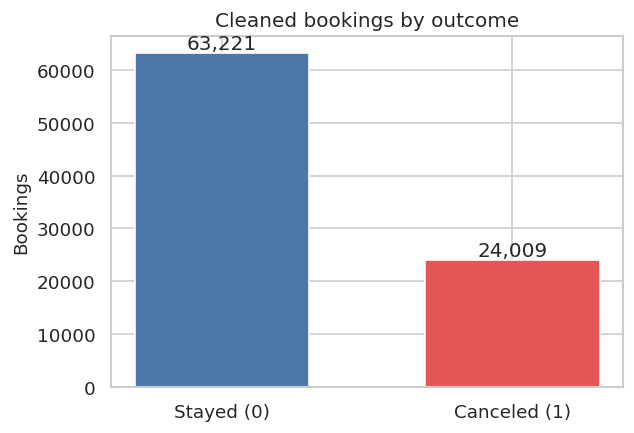

In [6]:
fig, ax = plt.subplots(figsize=(5.5, 3.8))
counts = df["is_canceled"].value_counts().sort_index()
bars = ax.bar(
    ["Stayed (0)", "Canceled (1)"],
    counts.values,
    color=[STAY, CANCEL],
    width=0.6,
)
ax.set_ylabel("Bookings")
ax.set_title("Cleaned bookings by outcome")
for bar, n in zip(bars, counts.values):
    ax.text(bar.get_x() + bar.get_width() / 2, n, f"{n:,}", ha="center", va="bottom")
fig.savefig(FIG_DIR / "target_counts.png")
plt.show()


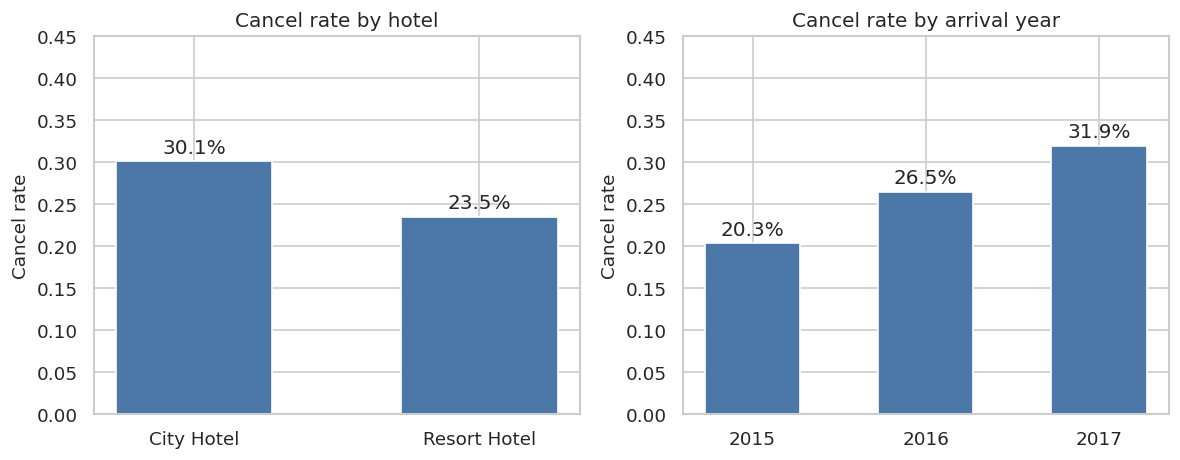

                   count      mean
arrival_date_year                 
2015               13284  0.203478
2016               42313  0.264694
2017               31633  0.319476


In [7]:
fig, axes = plt.subplots(1, 2, figsize=(10, 4))

hotel = (
    df.groupby("hotel")["is_canceled"]
    .mean()
    .reindex(["City Hotel", "Resort Hotel"])
)
axes[0].bar(hotel.index, hotel.values, color=STAY, width=0.55)
axes[0].set_ylim(0, 0.45)
axes[0].set_ylabel("Cancel rate")
axes[0].set_title("Cancel rate by hotel")
for i, v in enumerate(hotel.values):
    axes[0].text(i, v + 0.01, f"{v:.1%}", ha="center")

year = df.groupby("arrival_date_year")["is_canceled"].agg(["count", "mean"])
axes[1].bar(year.index.astype(str), year["mean"], color=STAY, width=0.55)
axes[1].set_ylim(0, 0.45)
axes[1].set_ylabel("Cancel rate")
axes[1].set_title("Cancel rate by arrival year")
for i, v in enumerate(year["mean"]):
    axes[1].text(i, v + 0.01, f"{v:.1%}", ha="center")

fig.tight_layout()
fig.savefig(FIG_DIR / "cancel_rate_by_hotel.png")
plt.show()
print(year)


City hotel cancels more than the resort (30.1% vs 23.5%). The year plot is
why I am not doing a random 70/30 split: 2015 is 20.3%, 2016 is 26.5%, 2017
is 31.9%. 2015 also only has July–December and 2017 only has January–August.


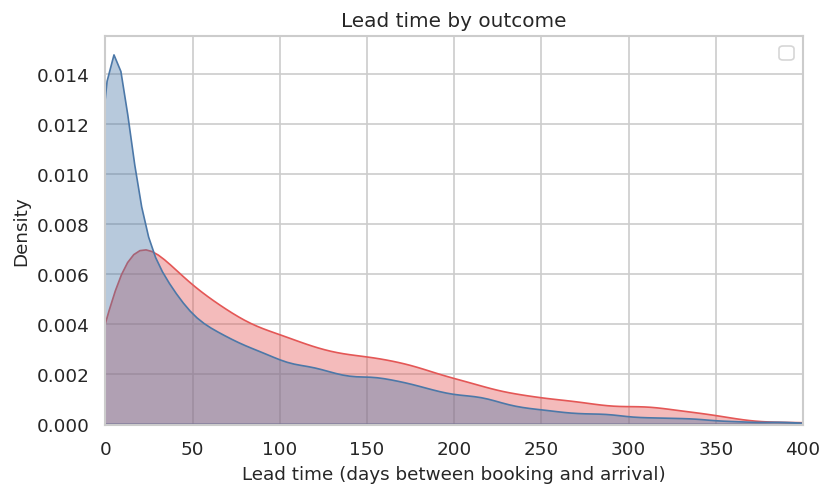

median lead time
is_canceled
0    38.0
1    80.0
Name: lead_time, dtype: float64

          count      mean
lead_bin                 
0–7       18203  0.084162
8–30      16326  0.253890
31–90     22720  0.320423
91–180    18224  0.350088
181–365   11193  0.396855
365+        564  0.407801


In [8]:
fig, ax = plt.subplots(figsize=(7.5, 4.2))
sns.kdeplot(
    data=df,
    x="lead_time",
    hue="is_canceled",
    common_norm=False,
    fill=True,
    alpha=0.4,
    palette={0: STAY, 1: CANCEL},
    ax=ax,
)
ax.set_xlim(0, 400)
ax.set_xlabel("Lead time (days between booking and arrival)")
ax.set_title("Lead time by outcome")
handles, _ = ax.get_legend_handles_labels()
ax.legend(handles, ["Stayed", "Canceled"], title="")
fig.savefig(FIG_DIR / "lead_time_by_cancel.png")
plt.show()

print("median lead time")
print(df.groupby("is_canceled")["lead_time"].median())

bins = [-1, 7, 30, 90, 180, 365, 10_000]
labels = ["0–7", "8–30", "31–90", "91–180", "181–365", "365+"]
lead = df.assign(lead_bin=pd.cut(df["lead_time"], bins=bins, labels=labels))
print()
print(lead.groupby("lead_bin", observed=True)["is_canceled"].agg(["count", "mean"]))


People who book far ahead cancel more. Median lead time is **80 days** for
cancels vs **38** for stayers. Same-week (0–7 days): **8.4%**. 181–365 days:
**39.7%**.


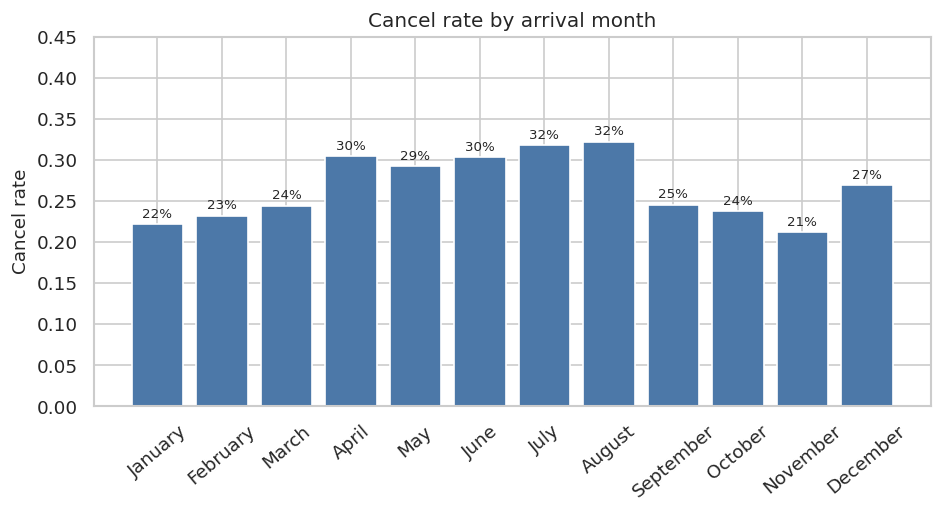

In [9]:
month_order = [
    "January", "February", "March", "April", "May", "June",
    "July", "August", "September", "October", "November", "December",
]
month = (
    df.groupby("arrival_date_month")["is_canceled"]
    .mean()
    .reindex(month_order)
)

fig, ax = plt.subplots(figsize=(9, 4))
ax.bar(month.index, month.values, color=STAY)
ax.set_ylim(0, 0.45)
ax.set_ylabel("Cancel rate")
ax.set_title("Cancel rate by arrival month")
ax.tick_params(axis="x", rotation=40)
for i, v in enumerate(month.values):
    ax.text(i, v + 0.008, f"{v:.0%}", ha="center", fontsize=8)
fig.savefig(FIG_DIR / "cancel_rate_by_month.png")
plt.show()


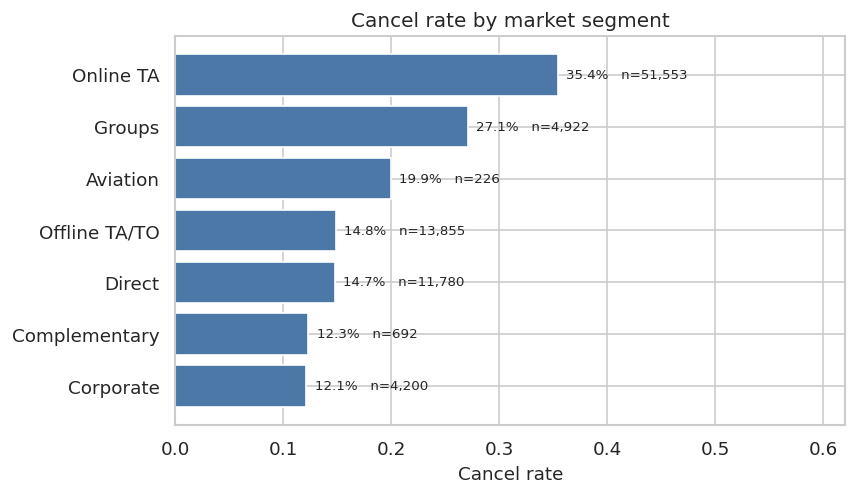

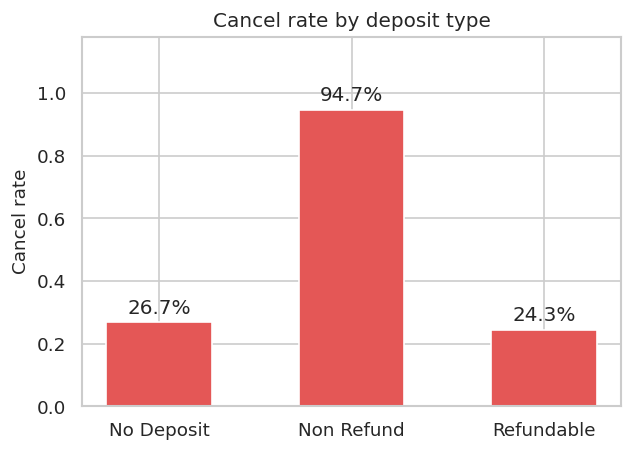

                count      mean
market_segment                 
Other               2  1.000000
Online TA       51553  0.353849
Groups           4922  0.270622
Aviation          226  0.199115
Offline TA/TO   13855  0.148466
Direct          11780  0.147453
Complementary     692  0.122832
Corporate        4200  0.121190

              count      mean
deposit_type                 
No Deposit    86085  0.267178
Non Refund     1038  0.947013
Refundable      107  0.242991


In [10]:
market = (
    df.groupby("market_segment")["is_canceled"]
    .agg(["count", "mean"])
    .sort_values("mean", ascending=False)
)
# Other is 2 rows — skip it on the chart
market_plot = market.drop(index=["Other"], errors="ignore")

fig, ax = plt.subplots(figsize=(7.2, 4.2))
ax.barh(market_plot.index[::-1], market_plot["mean"].iloc[::-1], color=STAY)
ax.set_xlabel("Cancel rate")
ax.set_title("Cancel rate by market segment")
ax.set_xlim(0, 0.62)
for i, (seg, row) in enumerate(market_plot.iloc[::-1].iterrows()):
    ax.text(row["mean"] + 0.008, i, f"{row['mean']:.1%}   n={int(row['count']):,}", va="center", fontsize=8)
fig.savefig(FIG_DIR / "cancel_rate_by_market.png")
plt.show()

deposit = df.groupby("deposit_type")["is_canceled"].agg(["count", "mean"])
fig, ax = plt.subplots(figsize=(5.8, 4.0))
ax.bar(deposit.index, deposit["mean"], color=CANCEL, width=0.55)
ax.set_ylim(0, 1.18)
ax.set_ylabel("Cancel rate")
ax.set_title("Cancel rate by deposit type")
for i, v in enumerate(deposit["mean"]):
    ax.text(i, min(v + 0.03, 1.12), f"{v:.1%}", ha="center")
fig.savefig(FIG_DIR / "cancel_rate_by_deposit.png")
plt.show()
print(market)
print()
print(deposit)


Online TA is the bulk of the table and cancels at **35.4%**. Direct is
**14.7%**, corporate **12.1%**.

`Non Refund` cancels **94.7%** of the time, but that is only 1,038 cleaned
rows (the raw file had ~14.5k, mostly duplicates). I would not go tell a
hotel “make deposits non-refundable and cancellations go away.” It looks
more like how those bookings were stored.


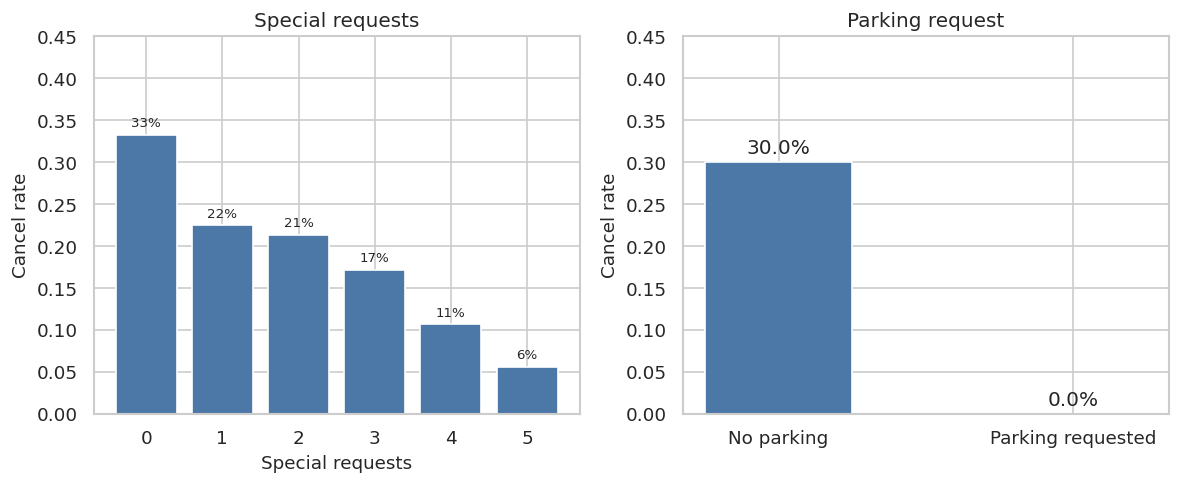

previous cancellations:
          count      mean
had_prev                 
False     85549  0.267285
True       1681  0.679952

Portuguese (PRT) cancel rate:
         count      mean
country                 
False    59875  0.237612
True     27355  0.357595


In [11]:
fig, axes = plt.subplots(1, 2, figsize=(10, 4.2))

sr = df.groupby("total_of_special_requests")["is_canceled"].agg(["count", "mean"])
axes[0].bar(sr.index.astype(str), sr["mean"], color=STAY)
axes[0].set_xlabel("Special requests")
axes[0].set_ylabel("Cancel rate")
axes[0].set_title("Special requests")
axes[0].set_ylim(0, 0.45)
for i, v in enumerate(sr["mean"]):
    axes[0].text(i, v + 0.01, f"{v:.0%}", ha="center", fontsize=8)

park = df.assign(parking=(df["required_car_parking_spaces"] > 0).map({False: "No parking", True: "Parking requested"}))
park_rate = park.groupby("parking")["is_canceled"].agg(["count", "mean"])
axes[1].bar(park_rate.index, park_rate["mean"], color=STAY, width=0.5)
axes[1].set_ylim(0, 0.45)
axes[1].set_ylabel("Cancel rate")
axes[1].set_title("Parking request")
for i, v in enumerate(park_rate["mean"]):
    axes[1].text(i, v + 0.01, f"{v:.1%}", ha="center")

fig.tight_layout()
fig.savefig(FIG_DIR / "cancel_rate_by_special_requests.png")
plt.show()

prev = df.assign(had_prev=(df["previous_cancellations"] > 0))
print("previous cancellations:")
print(prev.groupby("had_prev")["is_canceled"].agg(["count", "mean"]))
print()
print("Portuguese (PRT) cancel rate:")
print(df.groupby(df["country"] == "PRT")["is_canceled"].agg(["count", "mean"]))


Special requests line up the way you would expect: 0 requests → **33.3%**
cancel, 3+ → **16.2%**.

Parking requested: **0%** cancels on 7,306 rows. That is a huge flag. I
still keep the column because the guest asks for parking at booking time.
I just do not believe the causal story (“give them a parking space and they
will show up”).

Portuguese guests cancel more than the rest (35.8% vs 23.8%). The hotels
are in Portugal, so that is domestic, not “international.”


## 4. Features

Only things a front desk / booking engine would know when the reservation
is created.

A few extra columns I am adding:

- `total_nights`, `total_guests`
- `is_domestic` — `country == "PRT"`
- `country_group` — keep the 10 most common countries, dump the rest in
  `Other` (there are 177 countries, one-hot of all of them is messy)
- `has_agent` — whether an agent ID is present. The ID itself is not useful
- `arrival_month_num` — month as 1–12

`company` is missing on 94% of rows, so I am not using it.


In [12]:
TOP_COUNTRIES = ["PRT", "GBR", "FRA", "ESP", "DEU", "ITA", "IRL", "BEL", "BRA", "NLD"]
MONTH_TO_NUM = {
    "January": 1, "February": 2, "March": 3, "April": 4, "May": 5, "June": 6,
    "July": 7, "August": 8, "September": 9, "October": 10, "November": 11, "December": 12,
}


def add_features(frame: pd.DataFrame) -> pd.DataFrame:
    out = frame.copy()
    out["total_nights"] = out["stays_in_weekend_nights"] + out["stays_in_week_nights"]
    out["total_guests"] = out["adults"] + out["children"] + out["babies"]
    out["has_kids"] = ((out["children"] + out["babies"]) > 0).astype(int)
    out["is_domestic"] = (out["country"] == "PRT").astype(int)
    out["country_group"] = out["country"].where(out["country"].isin(TOP_COUNTRIES), "Other")
    out["arrival_month_num"] = out["arrival_date_month"].map(MONTH_TO_NUM).astype(int)
    out["has_agent"] = out["agent"].notna().astype(int)
    return out


df = add_features(df)

NUMERIC = [
    "lead_time",
    "arrival_month_num",
    "arrival_date_day_of_month",
    "stays_in_weekend_nights",
    "stays_in_week_nights",
    "total_nights",
    "adults",
    "children",
    "babies",
    "total_guests",
    "previous_cancellations",
    "previous_bookings_not_canceled",
    "booking_changes",
    "days_in_waiting_list",
    "adr",
    "required_car_parking_spaces",
    "total_of_special_requests",
    "is_repeated_guest",
    "is_domestic",
    "has_kids",
    "has_agent",
]
CATEGORICAL = [
    "hotel",
    "meal",
    "market_segment",
    "distribution_channel",
    "reserved_room_type",
    "deposit_type",
    "customer_type",
    "country_group",
]
FEATURES = NUMERIC + CATEGORICAL
TARGET = "is_canceled"

print("numeric:", len(NUMERIC), "  categorical:", len(CATEGORICAL))


numeric: 21   categorical: 8


## 5. Train / test split

I am training on 2015–2016 arrivals and testing on 2017. That is closer to
how you would actually use this: score future bookings, not a random mix of
the same years.

I cap ADR at the **train** 99.9th percentile so a 5,400/night outlier does
not leak from test into the scaler / tree splits.


In [13]:
train = df[df["arrival_date_year"] < 2017].copy()
test = df[df["arrival_date_year"] == 2017].copy()

adr_cap = float(train["adr"].quantile(0.999))
train["adr"] = train["adr"].clip(upper=adr_cap)
test["adr"] = test["adr"].clip(upper=adr_cap)

X_train, y_train = train[FEATURES], train[TARGET].astype(int)
X_test, y_test = test[FEATURES], test[TARGET].astype(int)

print(f"train: {len(train):,} rows, cancel rate {y_train.mean():.1%}")
print(f"test:  {len(test):,} rows, cancel rate {y_test.mean():.1%}")
print(f"ADR cap (train 99.9th percentile): {adr_cap:.2f}")
print()
print("majority-class accuracy on 2017 (always predict stay):", round(1 - y_test.mean(), 4))


train: 55,597 rows, cancel rate 25.0%
test:  31,633 rows, cancel rate 31.9%
ADR cap (train 99.9th percentile): 308.74

majority-class accuracy on 2017 (always predict stay): 0.6805


## 6. Models

Three models, same features:

1. **Always stay** — sanity check. Accuracy will already look “okay”
2. **Logistic regression** — scaled numbers + one-hot categories,
   `class_weight="balanced"` so it does not ignore cancels
3. **Random forest** — same one-hot, no scaling. This is the main model

I am not oversampling. Train is 25% canceled, which is imbalanced but not
rare. `class_weight="balanced"` is enough, and it only uses the training
rows.

Threshold is the default 0.5. I am not tuning it — that would need hotel
costs for a false alarm vs a missed cancel, which I do not have.


In [14]:
def evaluate(name, y_true, y_pred, y_proba):
    scores = {
        "model": name,
        "accuracy": accuracy_score(y_true, y_pred),
        "precision": precision_score(y_true, y_pred, zero_division=0),
        "recall": recall_score(y_true, y_pred, zero_division=0),
        "f1": f1_score(y_true, y_pred, zero_division=0),
        "roc_auc": roc_auc_score(y_true, y_proba),
    }
    tn, fp, fn, tp = confusion_matrix(y_true, y_pred).ravel()
    scores.update({"tn": int(tn), "fp": int(fp), "fn": int(fn), "tp": int(tp)})
    return scores


# --- baseline ---
dummy = DummyClassifier(strategy="most_frequent")
dummy.fit(X_train, y_train)
dummy_pred = dummy.predict(X_test)
dummy_scores = evaluate("Always stay", y_test, dummy_pred, np.zeros(len(y_test)))

# --- logistic regression ---
logreg = Pipeline(
    [
        (
            "prep",
            ColumnTransformer(
                [
                    ("num", StandardScaler(), NUMERIC),
                    ("cat", OneHotEncoder(handle_unknown="ignore", sparse_output=False), CATEGORICAL),
                ]
            ),
        ),
        (
            "model",
            LogisticRegression(max_iter=1000, class_weight="balanced", random_state=42),
        ),
    ]
)
logreg.fit(X_train, y_train)
logreg_proba = logreg.predict_proba(X_test)[:, 1]
logreg_pred = (logreg_proba >= 0.5).astype(int)
logreg_scores = evaluate("Logistic regression", y_test, logreg_pred, logreg_proba)

# --- random forest ---
forest = Pipeline(
    [
        (
            "prep",
            ColumnTransformer(
                [
                    ("num", "passthrough", NUMERIC),
                    ("cat", OneHotEncoder(handle_unknown="ignore", sparse_output=False), CATEGORICAL),
                ]
            ),
        ),
        (
            "model",
            RandomForestClassifier(
                n_estimators=200,
                max_depth=16,
                min_samples_leaf=5,
                class_weight="balanced",
                random_state=42,
                n_jobs=-1,
            ),
        ),
    ]
)
forest.fit(X_train, y_train)
forest_proba = forest.predict_proba(X_test)[:, 1]
forest_pred = (forest_proba >= 0.5).astype(int)
forest_scores = evaluate("Random forest", y_test, forest_pred, forest_proba)

results = pd.DataFrame([dummy_scores, logreg_scores, forest_scores]).set_index("model")
display_cols = ["accuracy", "precision", "recall", "f1", "roc_auc"]
results[display_cols].round(3)


,accuracy,precision,recall,f1,roc_auc
model,,,,,
Always stay,0.681,0.000,0.000,0.000,0.500
Logistic regression,0.713,0.536,0.746,0.624,0.801
Random forest,0.758,0.621,0.623,0.622,0.815


In [15]:
print("Random forest — 2017 classification report")
print(classification_report(y_test, forest_pred, digits=3, target_names=["stay", "cancel"]))
print("confusion matrix [stay, cancel] x [pred stay, pred cancel]")
print(confusion_matrix(y_test, forest_pred))
print()
print(results[["tn", "fp", "fn", "tp"]])


Random forest — 2017 classification report
              precision    recall  f1-score   support

        stay      0.823     0.821     0.822     21527
      cancel      0.621     0.623     0.622     10106

    accuracy                          0.758     31633
   macro avg      0.722     0.722     0.722     31633
weighted avg      0.758     0.758     0.758     31633

confusion matrix [stay, cancel] x [pred stay, pred cancel]
[[17683  3844]
 [ 3806  6300]]

                        tn    fp     fn    tp
model                                        
Always stay          21527     0  10106     0
Logistic regression  15006  6521   2566  7540
Random forest        17683  3844   3806  6300


The forest is the better ranker (AUC **0.815** vs 0.801). Logistic
regression catches more cancels (recall 0.75 vs 0.62) and throws more
false alarms. I am keeping the forest as the saved model.

Always-stay accuracy of 0.681 is the floor. Anything that only reports
accuracy on this problem is easy to oversell.


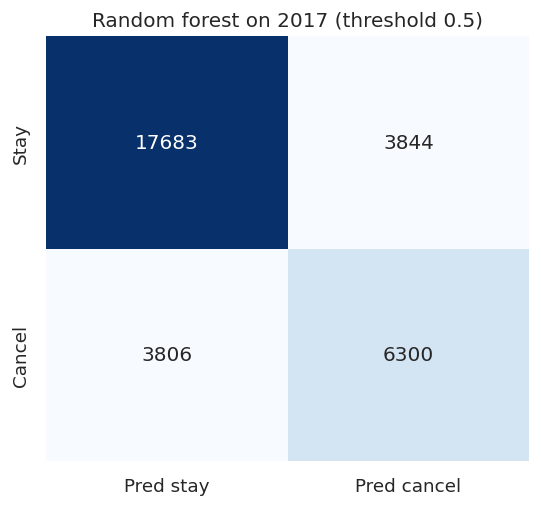

In [16]:
fig, ax = plt.subplots(figsize=(5.2, 4.6))
cm = confusion_matrix(y_test, forest_pred)
sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    cmap="Blues",
    cbar=False,
    xticklabels=["Pred stay", "Pred cancel"],
    yticklabels=["Stay", "Cancel"],
    ax=ax,
)
ax.set_title("Random forest on 2017 (threshold 0.5)")
fig.savefig(FIG_DIR / "confusion_matrix.png")
plt.show()


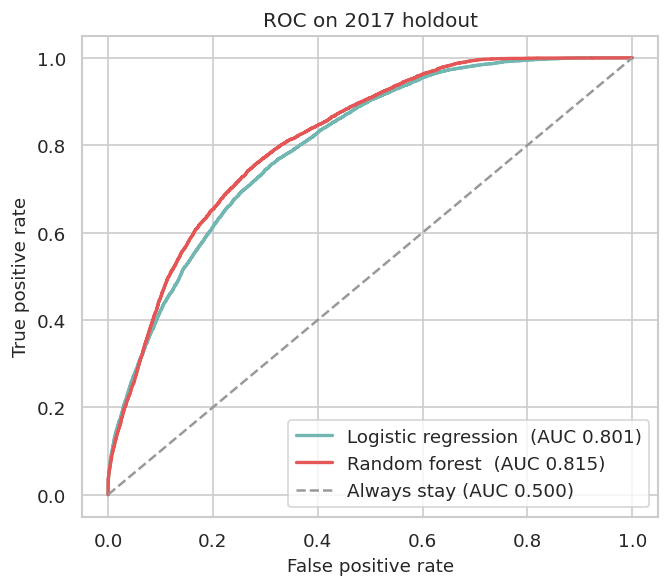

In [17]:
fig, ax = plt.subplots(figsize=(6.2, 5.2))
for scores, proba, color in [
    (logreg_scores, logreg_proba, "#72B7B2"),
    (forest_scores, forest_proba, CANCEL),
]:
    fpr, tpr, _ = roc_curve(y_test, proba)
    ax.plot(
        fpr,
        tpr,
        color=color,
        lw=2,
        label=f"{scores['model']}  (AUC {scores['roc_auc']:.3f})",
    )
ax.plot([0, 1], [0, 1], ls="--", c="0.6", label="Always stay (AUC 0.500)")
ax.set_xlabel("False positive rate")
ax.set_ylabel("True positive rate")
ax.set_title("ROC on 2017 holdout")
ax.legend(loc="lower right", frameon=True)
fig.savefig(FIG_DIR / "roc_curve.png")
plt.show()


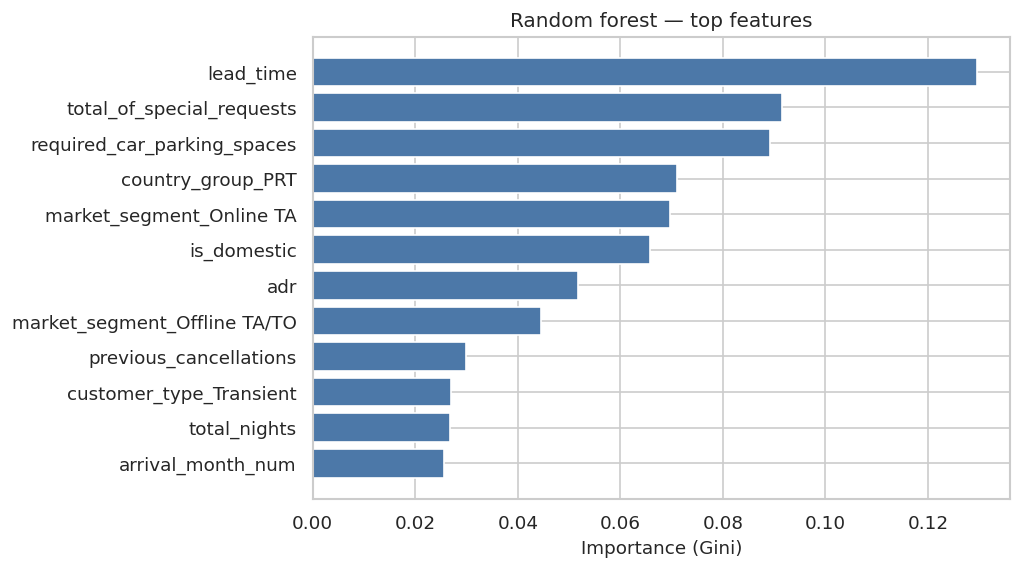

lead_time                       0.1296
total_of_special_requests       0.0916
required_car_parking_spaces     0.0892
country_group_PRT               0.0711
market_segment_Online TA        0.0697
is_domestic                     0.0657
adr                             0.0518
market_segment_Offline TA/TO    0.0446
previous_cancellations          0.0299
customer_type_Transient         0.0269
total_nights                    0.0268
arrival_month_num               0.0256
dtype: float64


In [18]:
ohe = forest.named_steps["prep"].named_transformers_["cat"]
feat_names = np.concatenate([NUMERIC, ohe.get_feature_names_out(CATEGORICAL)])
importances = forest.named_steps["model"].feature_importances_
imp = (
    pd.Series(importances, index=feat_names)
    .sort_values(ascending=True)
    .tail(12)
)

fig, ax = plt.subplots(figsize=(7.5, 5))
ax.barh(imp.index, imp.values, color=STAY)
ax.set_xlabel("Importance (Gini)")
ax.set_title("Random forest — top features")
fig.savefig(FIG_DIR / "feature_importance.png")
plt.show()
print(imp.sort_values(ascending=False).round(4))


Lead time is the strongest feature, then special requests, parking, and
whether the guest is Portuguese / booked through Online TA. That matches
the plots, which is a good sign.

Parking sitting near the top is the 0% cancel thing again. I would flag
that if I were handing this to a hotel, not quietly use it as a golden
rule.


In [19]:
# logistic coefficients, just to see the sign of a few things
ohe_lr = logreg.named_steps["prep"].named_transformers_["cat"]
lr_names = np.concatenate([NUMERIC, ohe_lr.get_feature_names_out(CATEGORICAL)])
coef = pd.Series(logreg.named_steps["model"].coef_[0], index=lr_names)
top = coef.reindex(coef.abs().sort_values(ascending=False).head(12).index)
print("logistic regression coefficients (top |coef|)")
print(top.round(3).to_string())


logistic regression coefficients (top |coef|)
required_car_parking_spaces    -3.776
deposit_type_Non Refund         2.075
deposit_type_Refundable        -1.688
market_segment_Online TA        1.065
distribution_channel_Other      0.914
deposit_type_No Deposit        -0.887
market_segment_Offline TA/TO   -0.849
is_domestic                     0.732
previous_cancellations          0.695
total_of_special_requests      -0.605
market_segment_Other            0.589
country_group_BRA               0.558


In [20]:
out_model = MODEL_DIR / "random_forest.joblib"
joblib.dump(forest, out_model)
print("saved", out_model.relative_to(ROOT))

# quick sanity check that it reloads
reloaded = joblib.load(MODEL_DIR / "random_forest.joblib")
check = reloaded.predict_proba(X_test.iloc[:5])[:, 1]
print("sample P(cancel) on 5 test rows:", np.round(check, 3))


saved models/random_forest.joblib
sample P(cancel) on 5 test rows: [0.759 0.189 0.189 0.83  0.203]


## 7. What I would not claim

- This is one 2017 holdout, not a full time-series CV.
- Q4 only exists in train. Summer is in both.
- `Non Refund` and parking are strong empirically and a little too strong
  to take at face value.
- I did not pick a threshold based on cost. 0.5 is just the default.
- The original extract has no prices paid, no reason for canceling, and no
  guest ID to build a real history beyond the two `previous_*` columns.

If I kept going, the next thing I would try is a year-based fold on
2015–2016 (train 2015, validate 2016) before touching 2017, and a
threshold picked from that validation fold.
